# Milestone 2: Dataset & Problem Approval
CSCI 3052U Machine Learning I, Team 7 "The Null Hypothesis"
Jason Badwal, Cort Auger, Saad Siddiqui, Adlene Oudahmane

This notebook covers what Milestone 2 asks for: data source and license, data card, sample inputs and outputs, initial EDA, the target and task, risks, the train/validation/test strategy, the primary metric, and a feasibility and compute plan.

The cleaning and splitting use the methods from the course, and each section is tagged with where its method comes from:
- [Lab 2] Data Engineering lab: pandas, `duplicated`, `isnull`, `missingno`, `fillna`, `drop`, `replace` with a mappings dict, `get_dummies`, `value_counts`, undersampling
- [Week 2] "Data is All You Need" lecture: the five kinds of bad data, imputation, imbalance, one-hot encoding, the design matrix, the train/val/test split, and the `x`/`t`/`y = h(x)` notation
- [Lab 3] / [Week 3] Nearest Neighbours: stratified split with `train_test_split`, normalization with the training-set mean/std plus `epsilon`, choosing models on validation only, and using the test set once

The task, features, split and metric come from our Milestone 1 Research Proposal (`docs/Research_Proposal.pdf`).

#We start by importing the necessary packages

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import missingno

%matplotlib inline

RANDOM_STATE = 42   # same seed as Lab 2 / Lab 3

# One fixed colour per class, used in every plot so a class never changes colour
CLASS_ORDER = ["Dropout", "Enrolled", "Graduate"]
CLASS_COLORS = {"Dropout": "#eb6834", "Enrolled": "#2a78d6", "Graduate": "#1baf7a"}

## 1. Data source and license

| | |
|---|---|
| Dataset | *Predict Students' Dropout and Academic Success*, UCI Machine Learning Repository, dataset #697 |
| URL | https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success |
| DOI | 10.24432/C5MC89 |
| Creators | V. Realinho, M. Vieira Martins, J. Machado, L. Baptista (2021) |
| Paper | Martins et al. (2021), *Early prediction of student's performance in higher education: a case study*, Trends and Applications in Information Systems and Technologies, Springer. DOI 10.1007/978-3-030-72657-7_16 |
| License | Creative Commons Attribution 4.0 (CC BY 4.0). We can use it for coursework as long as we credit the authors |
| Origin | One Portuguese higher-education institution, students who enrolled from 2008/09 to 2018/19. Funded by SATDAP (POCI-05-5762-FSE-000191) |
| Data we collected ourselves | None. The data is public and has no names, IDs or free text |

To get the file, download the zip from the URL above and extract `data.csv` to `data/predict+students+dropout+and+academic+success/data.csv`. The raw data isn't committed to git (see `.gitignore`), and the README walks through this step.

## 1.1 Data Card

The following data card summarizes the dataset, prediction task, preprocessing decisions, evaluation plan, and known limitations before model development.

| Item | Description |
|---|---|
| **Dataset** | *Predict Students' Dropout and Academic Success*, UCI Machine Learning Repository, Dataset #697 |
| **Creators** | V. Realinho, M. Vieira Martins, J. Machado, and L. Baptista (2021) |
| **License** | Creative Commons Attribution 4.0 (CC BY 4.0) |
| **Data origin** | One Portuguese higher-education institution. The dataset contains students enrolled between the 2008/09 and 2018/19 academic years. |
| **Unit of analysis** | One student's enrollment in an undergraduate degree program |
| **Number of observations** | 4,424 students |
| **Original variables** | 36 predictor variables and 1 target variable |
| **Prediction task** | Multiclass classification |
| **Target variable** | `Target` |
| **Target classes** | `Dropout`, `Enrolled`, and `Graduate` |
| **Class distribution** | Graduate ≈ 50%, Dropout ≈ 32%, Enrolled ≈ 18%. The classes are therefore imbalanced, particularly for the Enrolled class. |
| **Input information** | Application and admission information, demographic characteristics, socioeconomic information, and first-semester academic performance |
| **Prediction point** | After completion of the first semester. The goal is to identify students who may be at risk before later academic outcomes are known. |
| **Excluded information** | All second-semester curricular-unit variables are excluded because they occur after the intended prediction point and could leak information about the final outcome. |
| **Explicit missing values** | No explicit `NaN` values were found in the published dataset. |
| **Hidden/encoded missingness** | Some values require special interpretation, including Course 171 students with zero first-semester units and parent qualification/occupation codes representing unknown or blank responses. These cases are handled explicitly in the cleaning process. |
| **Duplicate observations** | No duplicate rows were found. |
| **Other preprocessing decisions** | `Nationality` is removed because it is redundant with `International`; sparse occupation codes are grouped; categorical variables are encoded for modelling; and continuous variables are normalized using statistics calculated from the training set only. |
| **Final model input** | After preprocessing and one-hot encoding, the current design matrix contains 169 features. |
| **Data split** | Stratified 70% training, 15% validation, and 15% testing |
| **Split sizes** | 3,096 training observations, 664 validation observations, and 664 test observations |
| **Random seed** | 42 |
| **Primary evaluation metric** | Macro-averaged F1 score |
| **Why macro-F1 is used** | Macro-F1 gives equal importance to Dropout, Enrolled, and Graduate instead of allowing the larger Graduate class to dominate the evaluation. |
| **Secondary evaluation evidence** | Per-class performance, Dropout recall, confusion matrices, variability across runs, and subgroup/error analysis |
| **Naive benchmark** | Majority-class prediction (`Graduate`). Its current validation macro-F1 is approximately 0.222. |
| **Intended use** | A research proof of concept for evaluating whether routinely available student information can help identify students who may benefit from earlier academic support. |
| **Non-intended use** | The model is not intended to automatically deny services, penalize students, or make other high-stakes decisions. Predictions should be interpreted as possible signals for supportive intervention rather than definitive judgments about individual students. |
| **Sensitive or potentially sensitive attributes** | Gender, age, marital status, international status, special-needs status, scholarship status, debtor/tuition status, and socioeconomic proxies such as parental occupation and qualification |
| **Main limitations** | The data comes from a single Portuguese institution, some categories contain very few students, the classes are imbalanced, some features may act as socioeconomic proxies, and results may not generalize to other institutions or countries. |
| **Fairness plan** | Report subgroup sizes and subgroup errors, investigate large performance gaps, and consider an ablation that removes socioeconomic proxy variables. |
| **Compute requirements** | The dataset is small enough to process using a standard laptop CPU with Python and scikit-learn. Individual experiments are expected to take seconds to minutes rather than requiring specialized hardware. |

### Data Card Summary

This dataset will work well for this project due to its availability under a license allowing for reuse with attribution, the size of the data that supports split into train/validate/test sets and the direct provision of all three output variables required for the classification problem.
The major drawbacks of this dataset include its class distribution (class imbalance), lack of generalizability, presence of both sensitive attributes and proxies for those attributes, low cardinality in many categorical features, and potential for an information leak from the use of some of the attributes. These issues are addressed through stratified splitting, macro-F1 evaluation, training-only preprocessing, exclusion of second-semester information, subgroup analysis, and explicit documentation of the dataset's limitations.

## 1.2 Prediction Point and Feature Availability

The purpose of this study will be to predict which students have a high likelihood of leaving school during their first year. It is our desire to do this soon enough after the end of a student’s first semester so that there can be some intervention from an advisor or college in order to help retain the student.

In order to make predictions that are reasonable for the time frame we are working with, it is necessary that we limit the variables used by the model to those items that would likely be known at least one month prior to the end of a student’s first semester. Variables such as application, admissions, demographics, socioeconomics and first-semester grades, etc., are acceptable variables to include.

Variables related to second-semester academic performance are excluded because they occur subsequent to the desired predictive time. Using second-semester grade data would provide the model with information that would not be available at the earliest possible opportunity (the end of a student's first semester) to allow for an early warning of potential drop-out behavior and therefore potentially cause information leakage.

| Feature Group | Available by Prediction Point? | Decision |
|---|---|---|
| Application and admission information | Yes | Keep |
| Demographic information | Yes | Keep, with fairness considerations |
| Socioeconomic information | Yes | Keep, with subgroup and proxy-bias analysis |
| First-semester academic performance | Yes | Keep |
| Second-semester academic performance | No | Exclude |

This feature-availability boundary will be kept consistent throughout model development so that all models are evaluated under the same realistic prediction scenario.

## 2. Load the data
#Load the data into a Pandas DataFrame. This file separates values with `;` instead of `,`, so we pass `sep=";"`. The path is relative to the repository, so it works on every team member's machine.

In [16]:
import os
import zipfile
import urllib.request
import pandas as pd

DATA_DIR = "../data/predict+students+dropout+and+academic+success"
DATA_PATH = os.path.join(DATA_DIR, "data.csv")

# Download dataset if it doesn't already exist
if not os.path.exists(DATA_PATH):
    os.makedirs(DATA_DIR, exist_ok=True)

    url = "https://archive.ics.uci.edu/static/public/697/predict+students+dropout+and+academic+success.zip"
    zip_path = "/tmp/student_dropout.zip"

    urllib.request.urlretrieve(url, zip_path)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(DATA_DIR)

df = pd.read_csv(DATA_PATH, sep=";", encoding="utf-8-sig")

print(type(df))
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
(4424, 37)


### 2.1 Dataset Version and File Fingerprint

To make the dataset version reproducible, we compute a SHA-256 fingerprint of the exact CSV file used in this project. If another team member downloads the same file, the hash should match. A different hash would indicate that the file contents are not identical.

In [17]:
import hashlib

with open(DATA_PATH, "rb") as f:
    dataset_sha256 = hashlib.sha256(f.read()).hexdigest()

print("Dataset SHA-256:", dataset_sha256)

Dataset SHA-256: 3ef126de5cefff26eb11fbb4237f1a1401cb64b488e2f1d598c23cedeb4c45ae


The SHA-256 value above identifies the exact dataset file used for all experiments in this project. This fingerprint will be recorded with the repository documentation so that future runs can verify that they are using the same dataset version.

#Choosing the Number of Rows to Observe

In [18]:
df.head(20)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
5,2,39,1,9991,0,19,133.1,1,37,37,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,Graduate
6,1,1,1,9500,1,1,142.0,1,19,38,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,Graduate
7,1,18,4,9254,1,1,119.0,1,37,37,...,0,5,5,0,0.000000,0,15.5,2.8,-4.06,Dropout
8,1,1,3,9238,1,1,137.0,62,1,1,...,0,6,7,6,14.142857,0,16.2,0.3,-0.92,Graduate
9,1,1,1,9238,1,1,138.0,1,1,19,...,0,6,14,2,13.500000,0,8.9,1.4,3.51,Dropout


In [19]:
df.shape

(4424, 37)

#We can view the total columns of a dataframe and their types

In [20]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [21]:
df.dtypes

,0
Marital status,int64
Application mode,int64
Application order,int64
Course,int64
Daytime/evening attendance\t,int64
Previous qualification,int64
Previous qualification (grade),float64
Nacionality,int64
Mother's qualification,int64
Father's qualification,int64


Each row is one student, i.e. one enrollment in an undergraduate degree. There are 4,424 students and 37 columns: 36 features plus the target (`Target`).

All the features are stored as numbers, but the [UCI data dictionary](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) shows that many of them are category codes. `Course = 171` means "Animation and Multimedia Design"; the 171 has no numeric meaning. Section 3.6 handles these.

## 3. Cleaning with the five kinds of bad data
The Week 2 lecture lists five things that make a dataset bad: junk values, redundant information, missing data, contextual errors and irrelevant information. We check this dataset for each one.

### 3.1 Junk values
Two column names have problems. One ends in an invisible tab character, and one is misspelled.

In [22]:
[c for c in df.columns if c != c.strip()]

['Daytime/evening attendance\t']

#We fix the column names with string methods (the same idea as `.str.replace` on `coordinates` in Lab 2) and rename the typo

In [23]:
df.columns = df.columns.str.strip()
df = df.rename(columns={"Nacionality": "Nationality"})
print([c for c in df.columns if c != c.strip()])
print("Nationality" in df.columns)

[]
True


### 3.2 Redundant information: duplicate rows
#In data analysis and filtering, it is often important to remove the repeated rows from our dataframe

In [24]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
4419,False
4420,False
4421,False
4422,False


In [25]:
duplicate_rows = df[df.duplicated()]
print(len(duplicate_rows))

0


In [26]:
df = df.drop_duplicates()
print("Shape after drop_duplicates:", df.shape)
print("Duplicate rows remaining:", df.duplicated().sum())

Shape after drop_duplicates: (4424, 37)
Duplicate rows remaining: 0


There are no duplicate rows, so `drop_duplicates()` keeps all 4,424 students. We leave the step in the pipeline in case a later version of the file has duplicates.

### 3.2b Redundant information: duplicate *columns*
Two different columns can also hold the same information. `Nationality` (code 1 = Portuguese) and `International` (1 = yes) might be one of those pairs, so we cross-tabulate them.

In [27]:
pd.crosstab(df["Nationality"] != 1, df["International"])

International,0,1
Nationality,,
False,4314,0
True,0,110


Every non-Portuguese student has `International = 1` and every Portuguese student has `International = 0`, so the two columns give the same yes/no answer. `Nationality` also splits the 110 international students across 20 country codes, and most of those codes have fewer than 10 students. We drop `Nationality` and keep `International`.

In [28]:
print(df["Nationality"].value_counts())
df = df.drop(columns="Nationality")

Nationality
1      4314
41       38
26       14
6        13
22       13
24        5
100       3
11        3
103       3
62        2
21        2
101       2
25        2
2         2
105       2
32        1
13        1
109       1
108       1
14        1
17        1
Name: count, dtype: int64


### 3.3 Missing data
#In Data Analysis, we should always remove/fill up null rows from our Dataframe. First we check whether there are any.

In [29]:
df.isnull().sum()

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Previous qualification (grade),0
Mother's qualification,0
Father's qualification,0
Mother's occupation,0


<Axes: >

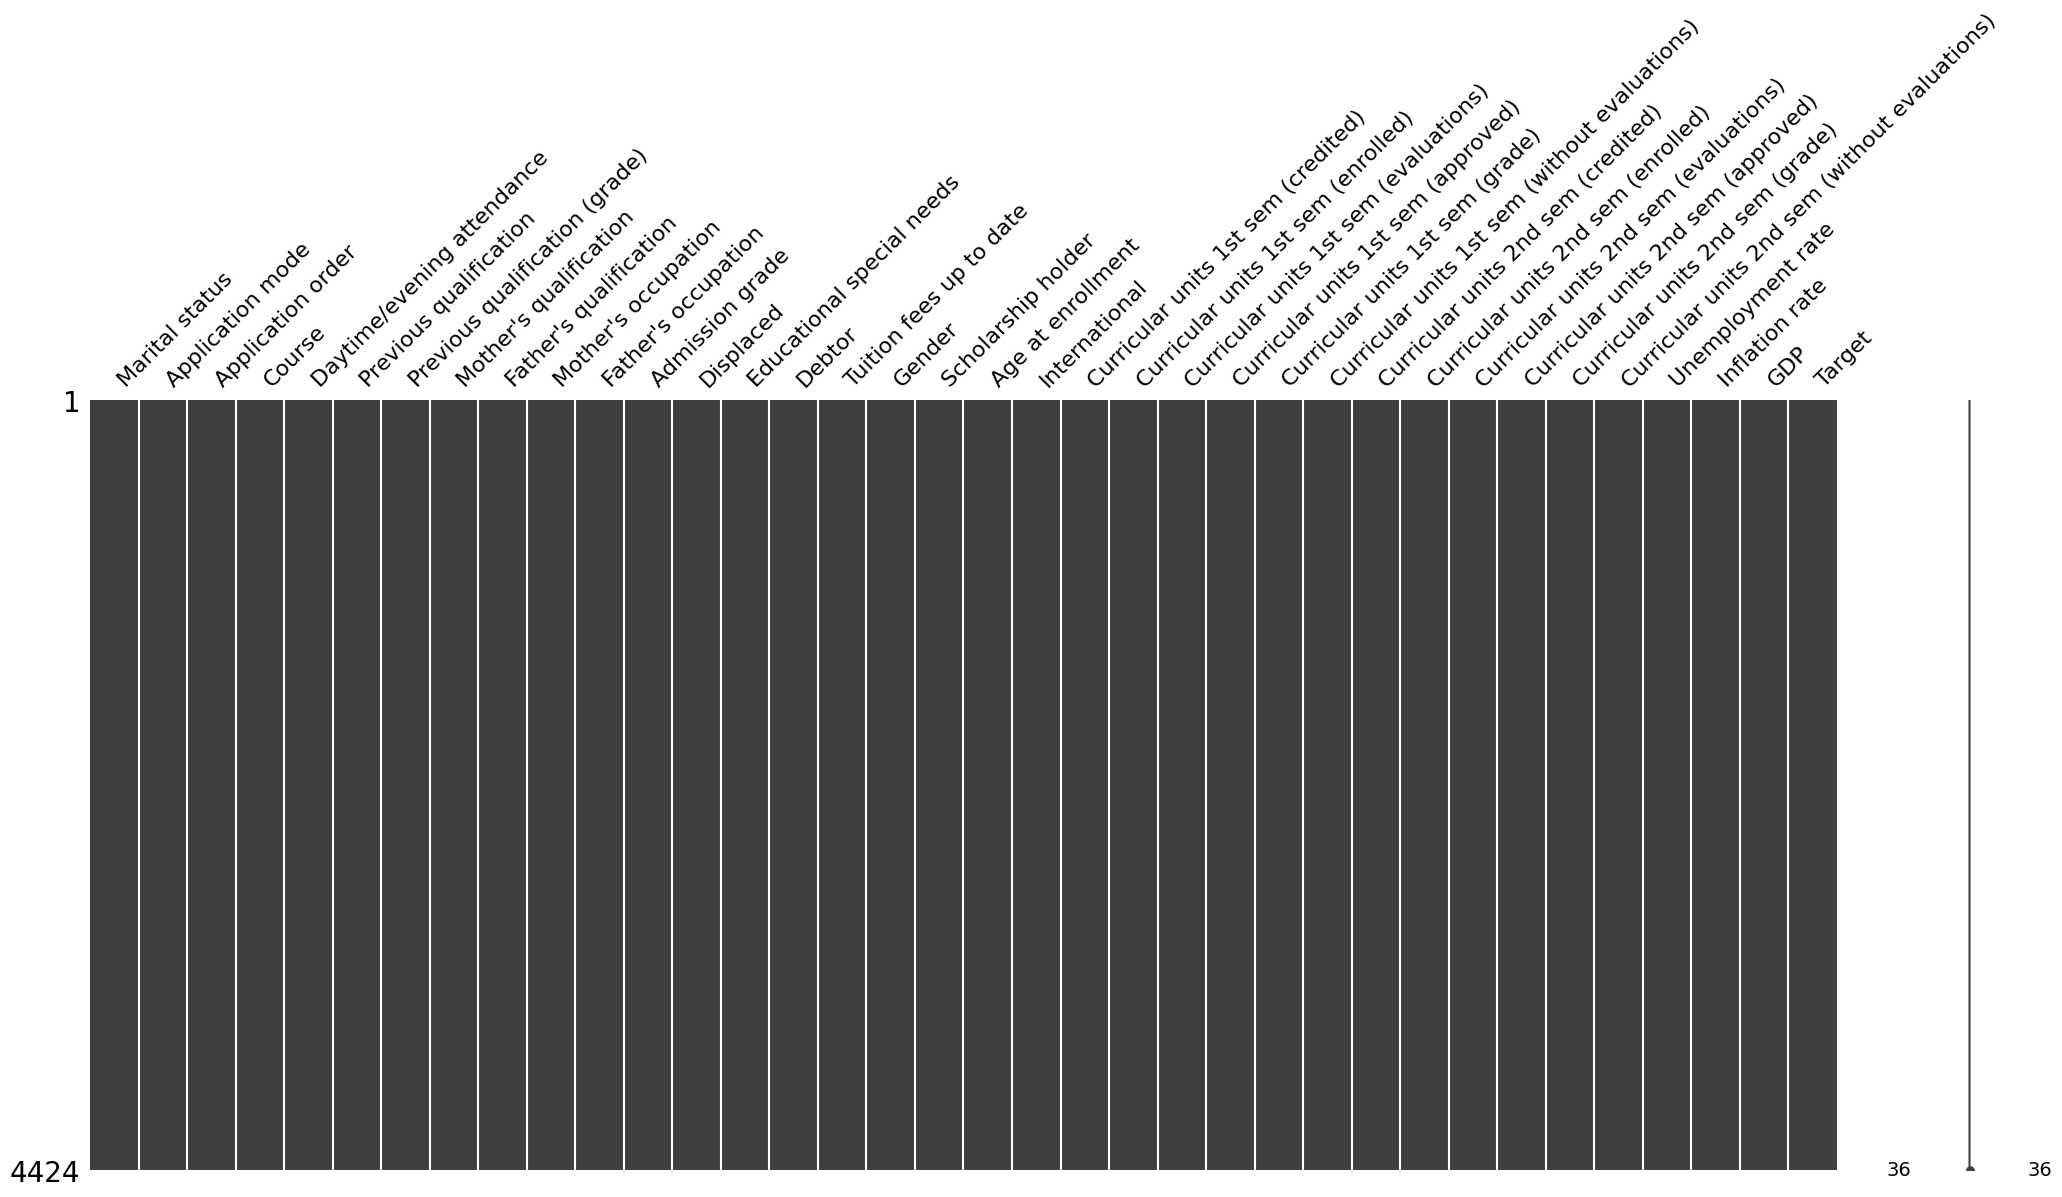

In [30]:
missingno.matrix(df)

No column has an empty (`NaN`) value. The UCI page says the authors handled missing values before publishing, so we don't need any of the Lab 2 imputation options (`fillna` with the mean, median or mode, or `dropna`).

A dataset with no NaNs can still have missing values hidden behind a code or a zero. The next section looks for those.

### 3.4 Contextual errors: values that look valid but make no sense
#Analysis of column containing numeric data

In [31]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000
Mother's occupation,4424.0,10.960895,26.418253,0.00,4.00,5.000000,9.000000,194.000000


The ranges match the data dictionary: admission and previous-qualification grades between 0 and 200, semester grades between 0 and 20, and ages from 17 to 70. A 70-year-old student is unusual but possible (59 students are 50 or older), so we keep them.

The first hidden-missing case is a semester grade of 0. A 1st-semester average of `0.0` could mean the student failed everything, or that they had no curricular units at all. We look at the students with 0 enrolled units:

In [32]:
no_units = df[df["Curricular units 1st sem (enrolled)"] == 0]
print("Students with 0 enrolled units in 1st sem:", len(no_units))
print(no_units["Curricular units 1st sem (grade)"].unique())
print(no_units["Course"].value_counts())

Students with 0 enrolled units in 1st sem: 180
[0.]
Course
171    180
Name: count, dtype: int64


In [33]:
print("Course 171 students in total:", (df["Course"] == 171).sum())
pd.crosstab(df["Curricular units 1st sem (enrolled)"] == 0, df["Target"])

Course 171 students in total: 215


Target,Dropout,Enrolled,Graduate
Curricular units 1st sem (enrolled),,,
False,1344,766,2134
True,77,28,75


All 180 of these students are in Course 171 (Animation and Multimedia Design). That is 180 of the course's 215 students, and they have 0 enrolled units in both semesters. Their outcomes cover all three classes: 77 Dropout, 28 Enrolled and 75 Graduate. Nobody graduates without taking any units, so this looks like a recording gap for one program, and their `grade = 0.0` is a contextual error.

The Lab 2 `missingno` plot shows this if we replace the 0s with `NaN` on a copy of the data:

<Axes: >

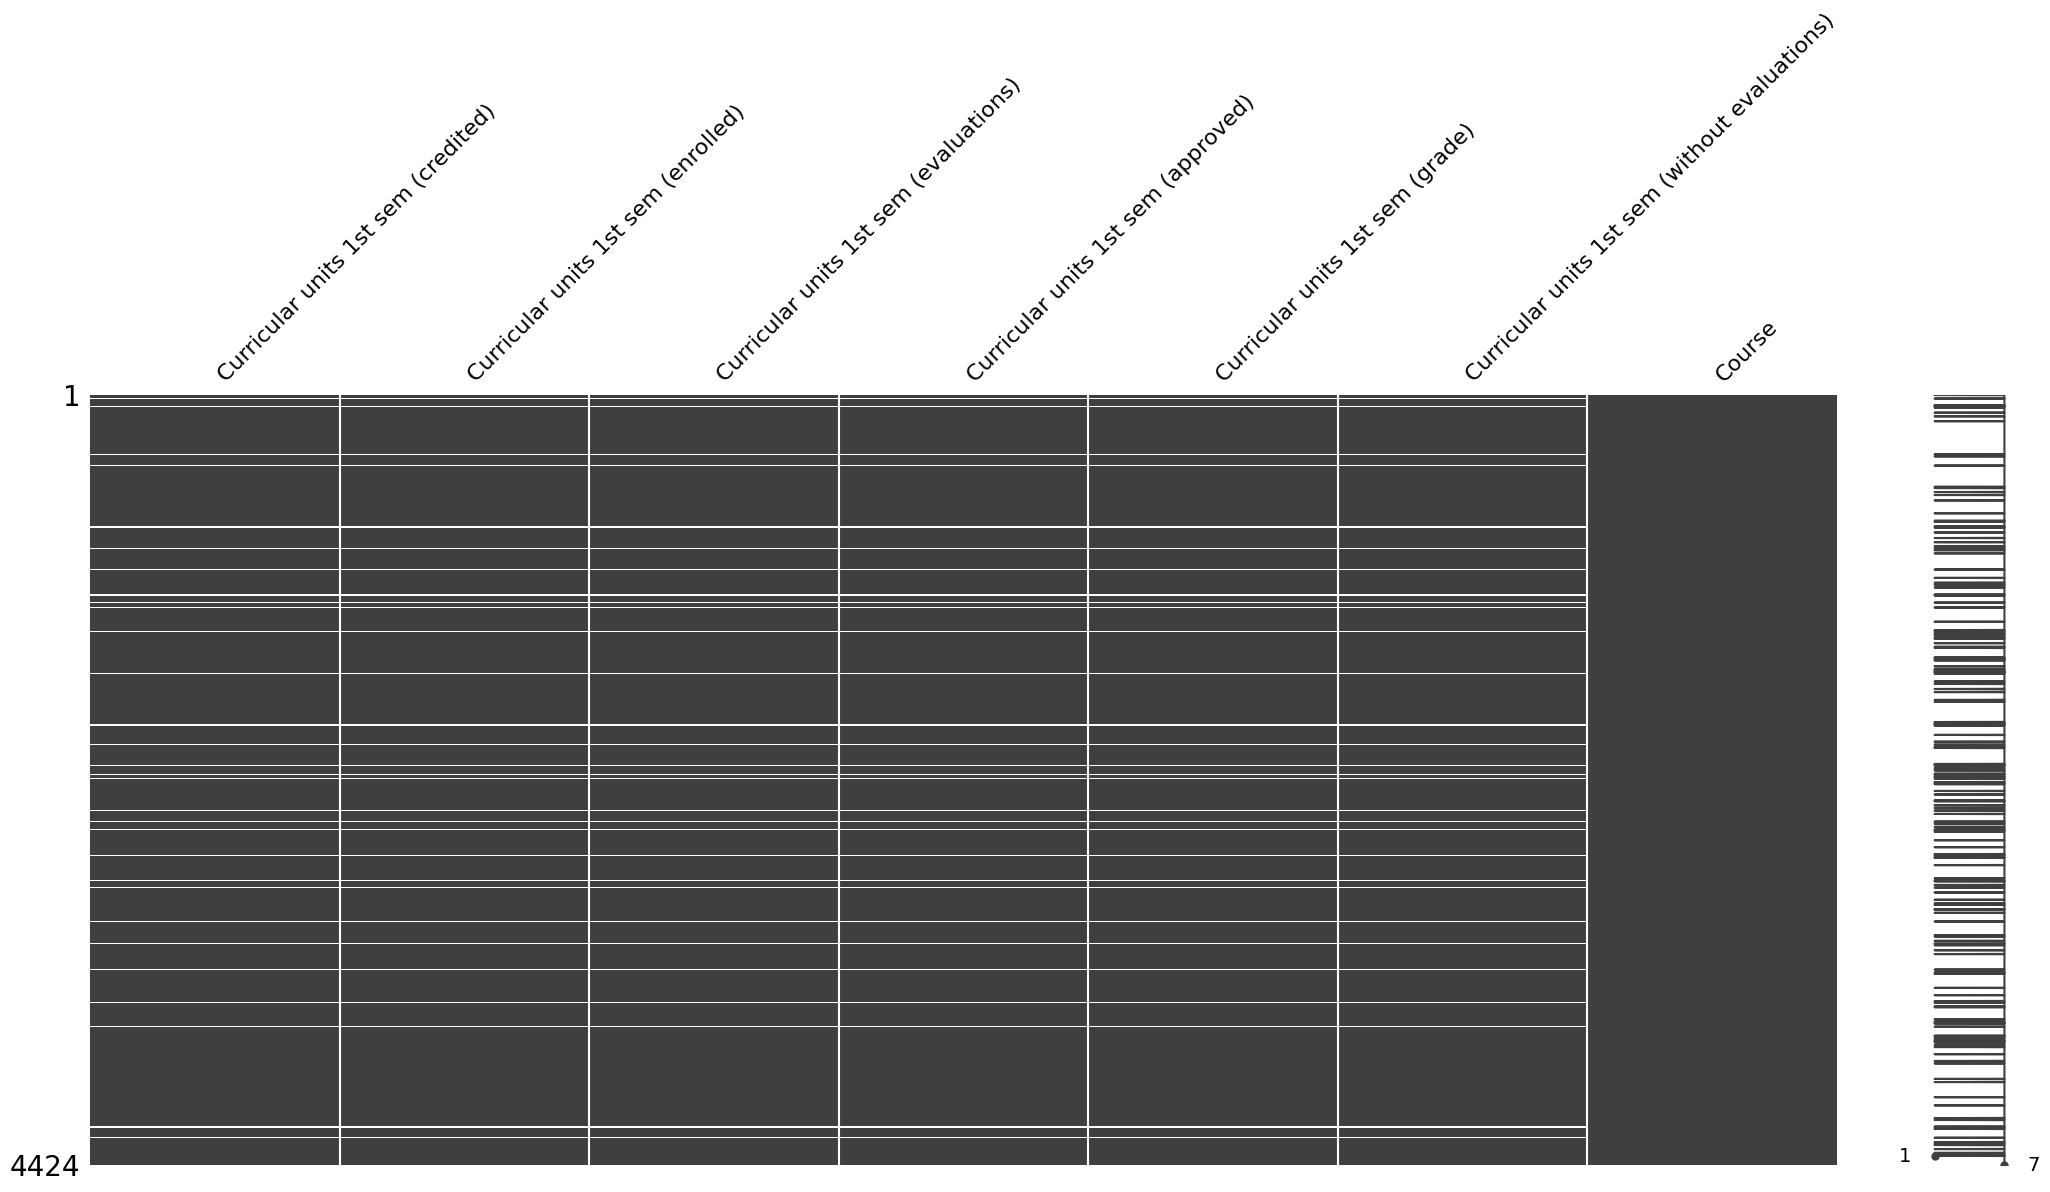

In [34]:
df_check = df.copy()
first_sem = [c for c in df.columns if "1st sem" in c]
df_check.loc[df_check["Curricular units 1st sem (enrolled)"] == 0, first_sem] = np.nan
missingno.matrix(df_check[first_sem + ["Course"]])

We considered the Week 2 / Lab 2 options for dealing with them:

| Option | Why we didn't pick it |
|---|---|
| Delete the records (`dropna`) | This would remove 84% of Course 171, and the model would then know nothing about that program. |
| Fill with the column mean or median (`fillna`) | This invents a grade for students with no recorded units. It would also have to be computed on the training data only, after splitting (see the Lab 3 normalization). |
| Draw a value at random | This also invents data. |

We keep the rows and add a 0/1 flag column, `no_units_1st_sem`, so a model can tell "no units recorded" apart from "failed everything". Course 171 also gets its own one-hot column, so the model can learn a program effect.

In [35]:
df["no_units_1st_sem"] = (df["Curricular units 1st sem (enrolled)"] == 0).astype(int)
df["no_units_1st_sem"].value_counts()

,count
no_units_1st_sem,
0,4244
1,180


The second hidden-missing case is the "Unknown" codes. The data dictionary has codes that stand for a missing answer: parent qualification `34 = Unknown` and parent occupation `99 = (blank)`.

In [36]:
print("Mother's qualification = Unknown:", (df["Mother's qualification"] == 34).sum())
print("Father's qualification = Unknown:", (df["Father's qualification"] == 34).sum())
print("Mother's occupation = blank:     ", (df["Mother's occupation"] == 99).sum())
print("Father's occupation = blank:     ", (df["Father's occupation"] == 99).sum())

Mother's qualification = Unknown: 130
Father's qualification = Unknown: 112
Mother's occupation = blank:      17
Father's occupation = blank:      19


These columns are categorical, so after one-hot encoding "Unknown" becomes a category with its own 0/1 column. We don't need to impute anything, and the model can learn whether an unknown answer is itself informative. The data card lists this as a limitation.

### 3.5 Irrelevant information: features outside our task
Our proposal frames the task as predicting the outcome from "information on record early in a student's time at the university", and asks whether "enrollment and first-semester data" can predict dropout risk. The six `Curricular units 2nd sem` columns describe the second semester, so a model that uses them can only warn advisors a full year in. They also give the outcome away: a student who left during semester 1 has 0 units in semester 2. For an early-warning task that counts as leakage, so we drop them.

We may add them back later as a comparison, to measure how much waiting one more semester improves the predictions.

#We can also drop specific columns of a dataframe

In [37]:
second_sem = [c for c in df.columns if "2nd sem" in c]
print(second_sem)
df = df.drop(columns=second_sem)
print(df.shape)

['Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)']
(4424, 31)


### 3.6 Categorical codes and readable labels
#We can access the unique values of a column

In [38]:
categorical_cols = ["Marital status", "Application mode", "Course", "Previous qualification",
                    "Mother's qualification", "Father's qualification",
                    "Mother's occupation", "Father's occupation"]

for col in categorical_cols:
    print(f"{col:25s} {len(df[col].unique()):3d} unique codes")

Marital status              6 unique codes
Application mode           18 unique codes
Course                     17 unique codes
Previous qualification     17 unique codes
Mother's qualification     29 unique codes
Father's qualification     34 unique codes
Mother's occupation        32 unique codes
Father's occupation        46 unique codes


The two occupation columns have 32 and 46 codes, and most of the codes are rare. The data dictionary nests them, with each 3-digit code belonging to one of 10 major occupation groups. For example, `122 Health professionals` and `123 Teachers` are both in group `2 Specialists in Intellectual and Scientific Activities`, and codes `101–103` are all Armed Forces. We collapse each code to its major group. The grouping comes from the dictionary and uses no statistics from the data, so it can't leak anything.

In [39]:
def occupation_group(code):
    if code < 100:            # 0-10, 90 (other), 99 (blank) are already major groups
        return code
    group = (code // 10) % 10 # middle digit: 122 -> 2, 175 -> 7
    return 10 if group == 0 else group   # 101-103 -> 10 Armed Forces

for col in ["Mother's occupation", "Father's occupation"]:
    df[col] = df[col].map(occupation_group)
    print(col, sorted(df[col].unique()))

Mother's occupation [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(90), np.int64(99)]
Father's occupation [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(90), np.int64(99)]


#Modifying values of column containing codes [Lab 2]. As with the `room_type` mappings in Lab 2, we use a `mappings` dict with `.replace()` to make a readable copy for the EDA plots. The model still uses the numeric and one-hot version.

In [40]:
mappings_yes_no = {0: "no", 1: "yes"}

df_eda = df.copy()
df_eda["Gender"] = df_eda["Gender"].replace({0: "female", 1: "male"})
df_eda["Daytime/evening attendance"] = df_eda["Daytime/evening attendance"].replace({0: "evening", 1: "daytime"})
for col in ["Displaced", "Educational special needs", "Debtor", "Tuition fees up to date",
            "Scholarship holder", "International"]:
    df_eda[col] = df_eda[col].replace(mappings_yes_no)
df_eda["Marital status"] = df_eda["Marital status"].replace(
    {1: "single", 2: "married", 3: "widower", 4: "divorced", 5: "facto union", 6: "legally separated"})
df_eda[["Gender", "Daytime/evening attendance", "Debtor", "Marital status", "Target"]].head()

,Gender,Daytime/evening attendance,Debtor,Marital status,Target
0,male,daytime,no,single,Dropout
1,male,daytime,no,single,Graduate
2,male,daytime,no,single,Dropout
3,female,daytime,no,single,Graduate
4,female,evening,no,married,Graduate


## 4. Target and task
This is supervised multi-class classification with 3 classes. The target is the student's status at the end of the normal duration of their course:

| `Target` | meaning | integer label `t` |
|---|---|---|
| Dropout | left before finishing | 0 |
| Enrolled | still enrolled after the normal duration (delayed) | 1 |
| Graduate | finished on time | 2 |

In [41]:
target_map = {"Dropout": 0, "Enrolled": 1, "Graduate": 2}
df["Target"].unique()

array(['Dropout', 'Graduate', 'Enrolled'], dtype=object)

## 5. Turning the data into vectors: one-hot encoding and the design matrix
ML algorithms need every example as a numeric vector. A category code like `Course = 9500` can't be used as a number, because kNN would then treat Nursing (9500) as closer to Oral Hygiene (9556) than to Agronomy (9003). As in Week 2, we one-hot encode the categorical columns with `pd.get_dummies` (Lab 2), which gives one 0/1 column per category.

The columns fall into three groups:

In [42]:
binary_cols = ["Daytime/evening attendance", "Displaced", "Educational special needs", "Debtor",
               "Tuition fees up to date", "Gender", "Scholarship holder", "International",
               "no_units_1st_sem"]

continuous_cols = ["Application order", "Previous qualification (grade)", "Admission grade",
                   "Age at enrollment",
                   "Curricular units 1st sem (credited)", "Curricular units 1st sem (enrolled)",
                   "Curricular units 1st sem (evaluations)", "Curricular units 1st sem (approved)",
                   "Curricular units 1st sem (grade)", "Curricular units 1st sem (without evaluations)",
                   "Unemployment rate", "Inflation rate", "GDP"]

# sanity check: every column except Target is in exactly one group
assert sorted(categorical_cols + binary_cols + continuous_cols + ["Target"]) == sorted(df.columns)
print(len(categorical_cols), "categorical,", len(binary_cols), "binary,", len(continuous_cols), "continuous")

8 categorical, 9 binary, 13 continuous


In [43]:
pd.get_dummies(df["Course"].astype(str), prefix="Course", dtype=int).head()

,Course_171,Course_33,Course_8014,Course_9003,Course_9070,Course_9085,Course_9119,Course_9130,Course_9147,Course_9238,Course_9254,Course_9500,Course_9556,Course_9670,Course_9773,Course_9853,Course_9991
0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [44]:
dummies = pd.get_dummies(df[categorical_cols].astype(str), dtype=int)
X = pd.concat([df[continuous_cols + binary_cols], dummies], axis="columns")
t = df["Target"].map(target_map)

print("Design matrix X:", X.shape)
print("Target vector t:", t.shape)

Design matrix X: (4424, 169)
Target vector t: (4424,)


`X` is the design matrix from Week 2, with one row per student and one column per feature. `t` holds the true labels.

`get_dummies` runs on the full dataset before the split. It only decides which columns exist (the list of possible codes, which the data dictionary also gives us) and doesn't learn any statistics from the data. Every step that does learn from the data, such as normalization, imputation or resampling, happens after the split and uses the training set only (Section 8).

## 6. Sample inputs and outputs
In the Week 2 notation each student is a pair $(\mathbf{x}^{(i)}, t^{(i)})$, an input vector $\mathbf{x}$ and its true label $t$. The model learns a hypothesis $h$ so that the prediction $y = h(\mathbf{x})$ matches $t$.

Here is one real student from each class. Only readable columns are shown; the full $\mathbf{x}$ has every column of `X`.

In [45]:
show_cols = ["Course", "Age at enrollment", "Admission grade", "Scholarship holder",
             "Tuition fees up to date", "Debtor",
             "Curricular units 1st sem (enrolled)", "Curricular units 1st sem (approved)",
             "Curricular units 1st sem (grade)", "Target"]

samples = df_eda.groupby("Target").sample(n=1, random_state=RANDOM_STATE)
samples[show_cols]

,Course,Age at enrollment,Admission grade,Scholarship holder,Tuition fees up to date,Debtor,Curricular units 1st sem (enrolled),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Target
178,9853,18,133.0,no,yes,no,6,5,12.40000,Dropout
1524,171,18,141.7,no,yes,no,0,0,0.00000,Enrolled
1911,9500,20,127.5,no,yes,no,8,8,12.48375,Graduate


In [46]:
i = samples.index[0]
print("x =", X.loc[i].values[:13], "... (", X.shape[1], "values in total )")
print("t =", t.loc[i], f"({df.loc[i, 'Target']})")

x = [  5.   141.   133.    18.     0.     6.     8.     5.    12.4    0.
   9.4   -0.8   -3.12] ... ( 169 values in total )
t = 0 (Dropout)


For a new student the system outputs $y = h(\mathbf{x}) \in \{0, 1, 2\}$ (Dropout / Enrolled / Graduate). An advising office would treat a predicted Dropout, or a predicted Enrolled (delayed), as a reason to reach out early.

## 7. Initial EDA
### 7.1 Class balance

In [47]:
print(df["Target"].value_counts())
print()
print((df["Target"].value_counts(normalize=True) * 100).round(1))

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Target
Graduate    49.9
Dropout     32.1
Enrolled    17.9
Name: proportion, dtype: float64


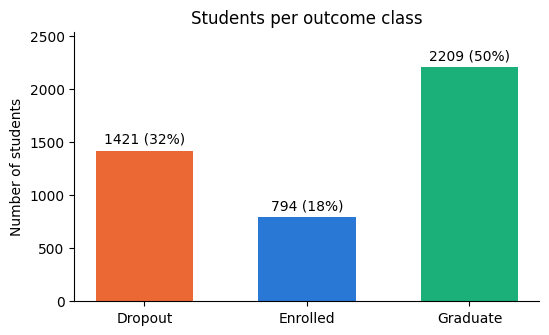

In [48]:
counts = df["Target"].value_counts().reindex(CLASS_ORDER)
fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(counts.index, counts.values, color=[CLASS_COLORS[c] for c in counts.index], width=0.6)
ax.bar_label(bars, labels=[f"{v} ({v / counts.sum():.0%})" for v in counts.values], padding=3)
ax.set_title("Students per outcome class")
ax.set_ylabel("Number of students")
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, counts.max() * 1.15)
plt.show()

### 7.2 How do the continuous features differ by outcome?

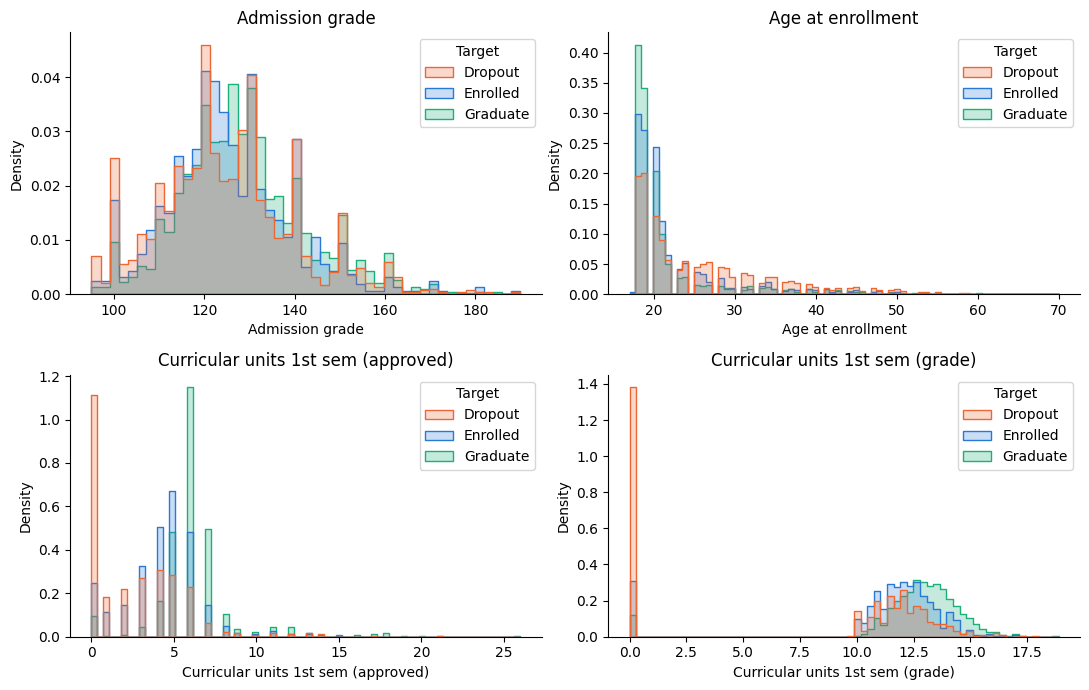

In [49]:
plot_cols = ["Admission grade", "Age at enrollment",
             "Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)"]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.flat, plot_cols):
    sns.histplot(data=df, x=col, hue="Target", hue_order=CLASS_ORDER, palette=CLASS_COLORS,
                 element="step", stat="density", common_norm=False, ax=ax)
    ax.set_title(col)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [50]:
df.groupby("Target")[plot_cols].median().reindex(CLASS_ORDER)

,Admission grade,Age at enrollment,Curricular units 1st sem (approved),Curricular units 1st sem (grade)
Target,,,,
Dropout,123.6,23.0,2.0,10.928571
Enrolled,124.1,20.0,5.0,12.000000
Graduate,127.4,19.0,6.0,13.000000


What the plots show:
- 1st-semester performance separates the classes the most. The median Dropout passes 2 units in the first semester and the median Graduate passes 6. The spike of Dropouts at grade 0 includes the Course 171 "no units" group from Section 3.4, which is why we flagged it.
- Dropouts are older. Their median age at enrollment is 23, against 19 for Graduates, most of whom enrolled at 18 to 20.
- Admission grade differs a little by class, but the distributions overlap heavily, so on its own it's a weak signal.

### 7.3 Binary and financial features vs outcome

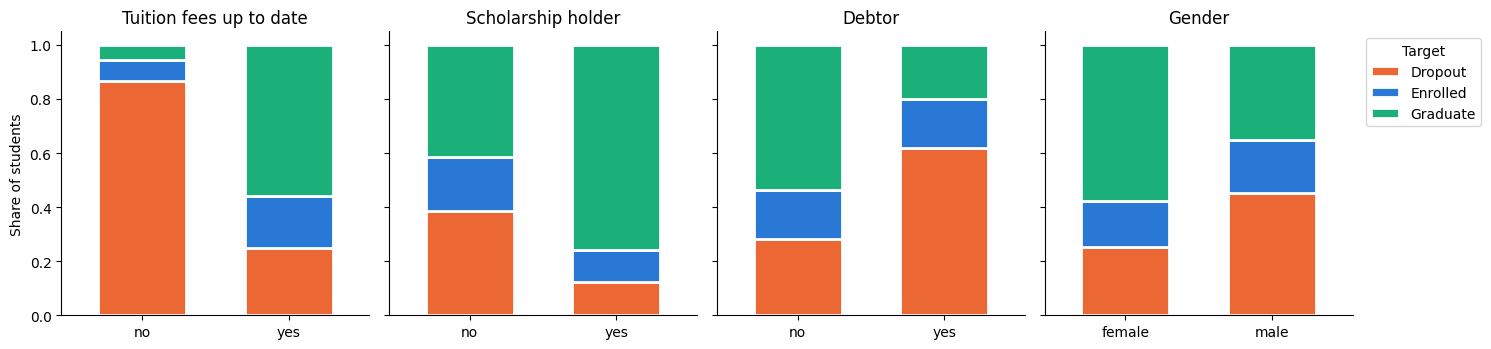

In [51]:
bin_plot = ["Tuition fees up to date", "Scholarship holder", "Debtor", "Gender"]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
for ax, col in zip(axes, bin_plot):
    rates = pd.crosstab(df_eda[col], df_eda["Target"], normalize="index")[CLASS_ORDER]
    rates.plot(kind="bar", stacked=True, ax=ax, color=[CLASS_COLORS[c] for c in CLASS_ORDER],
               legend=False, width=0.6, edgecolor="white", linewidth=2)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Share of students")
axes[-1].legend(title="Target", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [52]:
for col in bin_plot:
    print(pd.crosstab(df_eda[col], df_eda["Target"], normalize="index")[CLASS_ORDER].round(2), "\n")

Target                   Dropout  Enrolled  Graduate
Tuition fees up to date                             
no                          0.87      0.08      0.05
yes                         0.25      0.19      0.56 

Target              Dropout  Enrolled  Graduate
Scholarship holder                             
no                     0.39      0.20      0.41
yes                    0.12      0.12      0.76 

Target  Dropout  Enrolled  Graduate
Debtor                             
no         0.28      0.18      0.54
yes        0.62      0.18      0.20 

Target  Dropout  Enrolled  Graduate
Gender                             
female     0.25      0.17      0.58
male       0.45      0.20      0.35 



87% of students whose tuition isn't up to date are Dropouts, and 62% of debtors are Dropouts, against 28% of non-debtors. 76% of scholarship holders graduate. Financial status is a strong signal, and that also makes it a fairness concern (Section 12). Men drop out more often than women (45% vs 25%), which the subgroup analysis needs to account for.

### 7.4 Correlation between the continuous features

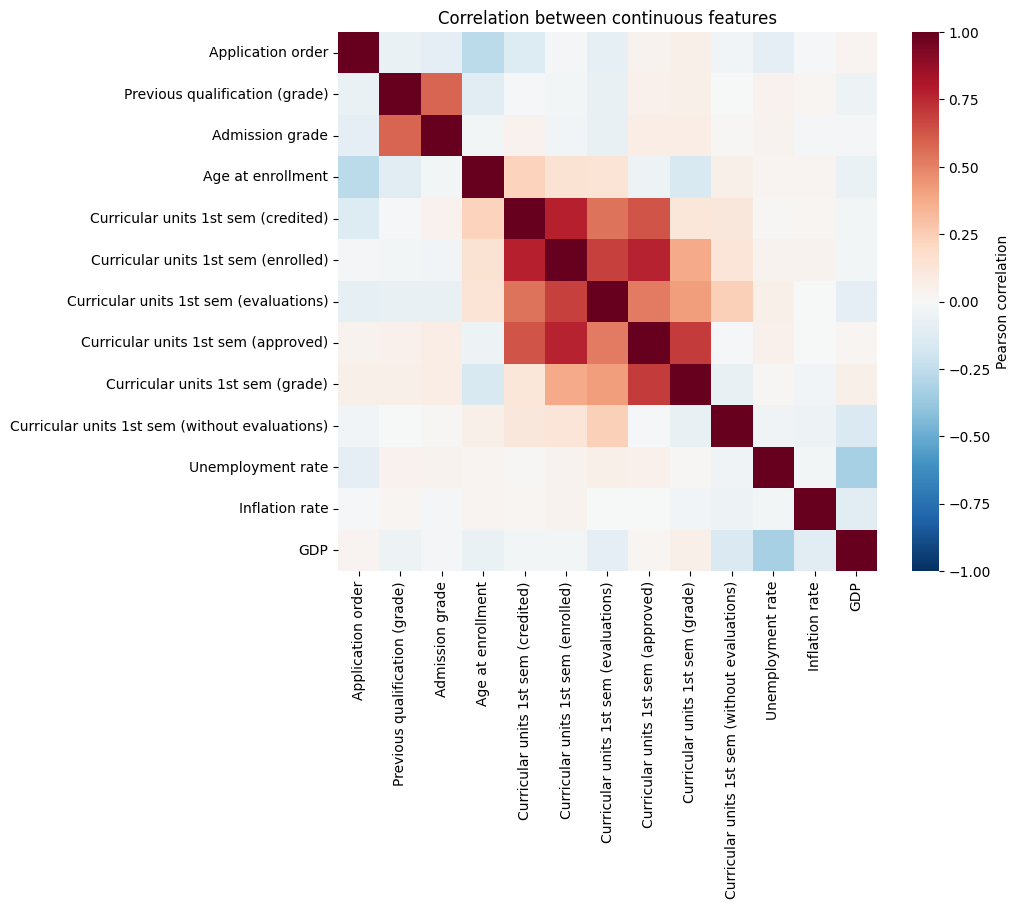

In [53]:
corr = df[continuous_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, cmap="RdBu_r", vmin=-1, vmax=1, center=0, square=True,
            cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title("Correlation between continuous features")
plt.show()

In [54]:
pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
pairs[pairs.abs() > 0.7].sort_values(ascending=False)

,,0
Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),0.774344
Curricular units 1st sem (enrolled),Curricular units 1st sem (approved),0.769083


The 1st-semester columns are strongly correlated with each other. Credited and enrolled, and enrolled and approved, are both at r ≈ 0.77. Approved and grade, and evaluations and enrolled, are at about 0.7. These columns all measure how much the student did in semester 1. kNN and decision trees can cope with that, but it will make logistic-regression weights harder to interpret, so it's a candidate for feature selection in Milestone 5. Previous-qualification grade and admission grade are moderately correlated (r ≈ 0.58).

### 7.5 Feature scales and the need for normalization [Week 3] [Lab 3]

In [55]:
df[continuous_cols].agg(["min", "max", "mean", "std"]).T.round(2)

,min,max,mean,std
Application order,0.00,9.00,1.73,1.31
Previous qualification (grade),95.00,190.00,132.61,13.19
Admission grade,95.00,190.00,126.98,14.48
Age at enrollment,17.00,70.00,23.27,7.59
Curricular units 1st sem (credited),0.00,20.00,0.71,2.36
Curricular units 1st sem (enrolled),0.00,26.00,6.27,2.48
Curricular units 1st sem (evaluations),0.00,45.00,8.30,4.18
Curricular units 1st sem (approved),0.00,26.00,4.71,3.09
Curricular units 1st sem (grade),0.00,18.88,10.64,4.84
Curricular units 1st sem (without evaluations),0.00,12.00,0.14,0.69


Admission grade runs from 95 to 190 while inflation rate runs from about -1 to 4. kNN uses Euclidean distance (Lab 3: $\textrm{dist}(\mathbf{v}, \mathbf{x}) = \sum_j (v_j - x_j)^2$), so without rescaling, admission grade would dominate every distance. Week 3 covered kNN's sensitivity to feature scale, and in Lab 3 the normalized kNN did better than the unnormalized one. Section 8.2 normalizes the features.

### 7.6 Subgroups for the fairness check (from our proposal)
Our proposal's success criterion includes a subgroup error analysis showing "no large unexplained gaps across attributes such as prior qualification or parental education". Before modelling, we check whether those groups are big enough to measure.

In [56]:
print(df["Previous qualification"].value_counts().head(8))
print()
print(df["Mother's qualification"].value_counts().head(8))

Previous qualification
1     3717
39     219
19     162
3      126
12      45
40      40
42      36
2       23
Name: count, dtype: int64

Mother's qualification
1     1069
37    1009
19     953
38     562
3      438
34     130
2       83
4       49
Name: count, dtype: int64


In [57]:
pd.crosstab(df["Previous qualification"], df["Target"], margins=True).sort_values("All", ascending=False).head(6)

Target,Dropout,Enrolled,Graduate,All
Previous qualification,,,,
All,1421,794,2209,4424
1,1078,698,1941,3717
39,69,55,95,219
19,104,13,45,162
3,75,4,47,126
12,26,6,13,45


84% of students have previous qualification code 1 (secondary education), and many codes have fewer than 10 students. After a 15% test split a rare group could be down to 1 or 2 students, too few to measure an error rate. The subgroup analysis will compare large groups instead, for example secondary vs. other previous qualifications, or parents with vs. without higher education, and will report the group size next to every subgroup score.

#### Planned Subgroup Evaluation Procedure

Planned Subgroups are to be evaluated at the beginning of the project prior to model building. In order to evaluate subgroups (in this case student demographics) prior to examining the final results from the model.

For all student demographics within the scope of this study, we plan to provide the following information:

- the number of students in the subgroup,
- macro-F1,
- recall for the Dropout class,
- and the absolute performance gap between the compared groups.

Student demographics consisting of very small numbers of students will not be individually analyzed due to instability in the estimation of their performance metrics. Student demographics with too few instances will either be aggregated into larger categories that are documented; or they will be described but no definitive conclusion will be drawn regarding the performance of the model.

The primary planned comparisons consist of:

- previous qualification: secondary education vs. other qualifications,
- parental education: higher-education background vs. no higher-education background,
- gender,
- scholarship status,
- debtor status,
- tuition-fee status,
- and international status where the subgroup size is sufficient.

Any perceived variation in observed performance will be considered as a basis for further investigation into whether the model itself is fair or unfair. An additional consideration we will make regarding our experiments is removing socioeconomic proxy variables (such as parental occupation/ qualification and financial status) from our data and determining how significantly these variables affect predictive performance.

## 8. Train / validation / test strategy
Following our proposal and the Week 2 lecture, we split the data 70% train, 15% validation and 15% test:
- The models learn from the training set.
- The validation set is for choosing models and hyperparameters, such as $k$ in kNN (Lab 3 Part 4).
- The test set is used once, at the end of the project (Milestone 5), to report final performance.

We call `train_test_split` twice, the same way `load_data()` does in Lab 3 Task 2: first we set aside 30%, then we split that 30% in half.

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_rest, t_train, t_rest = train_test_split(
    X, t, test_size=0.3, stratify=t, random_state=RANDOM_STATE)
X_valid, X_test, t_valid, t_test = train_test_split(
    X_rest, t_rest, test_size=0.5, stratify=t_rest, random_state=RANDOM_STATE)

X_train.shape, t_train.shape, X_valid.shape, t_valid.shape, X_test.shape, t_test.shape

((3096, 169), (3096,), (664, 169), (664,), (664, 169), (664,))

### Split Integrity and Leakage Checks

Before preprocessing or model training, we verify that the training, validation, and test sets are completely separate and contain the expected features. These checks help ensure that the evaluation remains reproducible and that information from the validation or test sets does not accidentally enter the training process.

In [59]:
assert len(X_train) + len(X_valid) + len(X_test) == len(X)
assert len(t_train) + len(t_valid) + len(t_test) == len(t)

assert set(X_train.index).isdisjoint(X_valid.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_valid.index).isdisjoint(X_test.index)

assert list(X_train.columns) == list(X_valid.columns)
assert list(X_train.columns) == list(X_test.columns)

assert not any("2nd sem" in str(col).lower() for col in X_train.columns)

assert X_train.isnull().sum().sum() == 0
assert X_valid.isnull().sum().sum() == 0
assert X_test.isnull().sum().sum() == 0

print("All split-integrity and leakage checks passed.")
print(f"Training observations:   {len(X_train)}")
print(f"Validation observations: {len(X_valid)}")
print(f"Test observations:       {len(X_test)}")

All split-integrity and leakage checks passed.
Training observations:   3096
Validation observations: 664
Test observations:       664


In [60]:
split_balance = pd.DataFrame({
    "full":  t.value_counts(normalize=True),
    "train": t_train.value_counts(normalize=True),
    "valid": t_valid.value_counts(normalize=True),
    "test":  t_test.value_counts(normalize=True),
}).rename(index={v: k for k, v in target_map.items()}).round(3)
split_balance

,full,train,valid,test
Target,,,,
Graduate,0.499,0.499,0.500,0.498
Dropout,0.321,0.321,0.321,0.322
Enrolled,0.179,0.180,0.179,0.179


Why shuffle? The rows might be ordered, for example by enrollment year or by course. Without shuffling, the test set could end up holding only the last few years or a single program. `train_test_split` shuffles by default.

Why stratify? With an 18% minority class, a plain random split could leave the validation set with very few Enrolled students, which would make every score on it noisy. Stratifying keeps the class proportions the same in all three splits, as the table above shows.

### 8.1 Should we undersample?
In Lab 2 we balanced the stroke data by undersampling the majority class. Here is the same code, applied to the training set only. Resampling the validation or test set would make our scores misleading.

In [61]:
train_df = X_train.assign(Target=t_train)
minority_size = train_df["Target"].value_counts().min()

balanced_parts = [part.sample(n=minority_size, random_state=RANDOM_STATE)
                  for _, part in train_df.groupby("Target")]
balanced_df = pd.concat(balanced_parts)
balanced_df = balanced_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(balanced_df["Target"].value_counts())
print(f"Training rows: {len(train_df)} -> {len(balanced_df)} "
      f"({1 - len(balanced_df) / len(train_df):.0%} of the training data thrown away)")

Target
1    556
0    556
2    556
Name: count, dtype: int64
Training rows: 3096 -> 1668 (46% of the training data thrown away)


#We balanced the dataset by removing observations from the majority class. This makes the classes equal, but we also lose a large amount of data.

For now, we are going to maintain the natural class distribution for the baseline. We do not want to lose nearly half of our training data (and most of the Graduate cases) by using undersampling. In addition, we do not want to introduce a distortion in the actual base-rates that an advisor will be dealing with. Instead, stratified splits and macro-F1 will address this issue. Whether undersampling, or class-weights produce better macro-F1 is to be determined through experimentation as part of Milestone 5, based on the validation set.

### 8.2 Normalizing the data without leakage
We normalize each continuous feature to mean 0 and standard deviation 1. The mean and std come from the training set only, and we apply those same numbers to validation and test.

#Why is it a bad idea to use all the data (including test) for the mean/std? Statistics from the test set would leak into training, and the test score would no longer be an honest estimate on unseen data. The normalization parameters are part of the model.

#Why `epsilon`? To avoid dividing by a standard deviation of 0.

Only the continuous columns get normalized. The 0/1 binary and one-hot columns stay as they are.

In [62]:
X_mean = X_train[continuous_cols].mean(axis=0)
X_std = X_train[continuous_cols].std(axis=0, ddof=0)
print(X_mean.shape)
print(X_std.shape)

(13,)
(13,)


In [63]:
epsilon = 0.0001

X_train_norm, X_valid_norm, X_test_norm = X_train.copy(), X_valid.copy(), X_test.copy()
X_train_norm[continuous_cols] = (X_train[continuous_cols] - X_mean) / (X_std + epsilon)
X_valid_norm[continuous_cols] = (X_valid[continuous_cols] - X_mean) / (X_std + epsilon)
X_test_norm[continuous_cols]  = (X_test[continuous_cols]  - X_mean) / (X_std + epsilon)

In [64]:
# check: training columns now have mean ~0 and std ~1; validation is close but not exact (expected)
pd.DataFrame({
    "train mean": X_train_norm[continuous_cols].mean(),
    "train std":  X_train_norm[continuous_cols].std(ddof=0),
    "valid mean": X_valid_norm[continuous_cols].mean(),
}).round(3)

,train mean,train std,valid mean
Application order,-0.0,1.0,0.037
Previous qualification (grade),-0.0,1.0,-0.008
Admission grade,-0.0,1.0,0.024
Age at enrollment,-0.0,1.0,0.022
Curricular units 1st sem (credited),-0.0,1.0,0.007
Curricular units 1st sem (enrolled),-0.0,1.0,0.038
Curricular units 1st sem (evaluations),0.0,1.0,0.023
Curricular units 1st sem (approved),-0.0,1.0,0.036
Curricular units 1st sem (grade),0.0,1.0,0.013
Curricular units 1st sem (without evaluations),-0.0,1.0,-0.043


## 9. Save the splits for reproducibility
We save the processed splits, which aren't committed because they're derived from the raw data. We also save the row indices of each split, which are committed, so anyone can rebuild the same split.

In [65]:
import json, os

os.makedirs("../data/processed", exist_ok=True)
for name, Xs, ts in [("train", X_train_norm, t_train), ("valid", X_valid_norm, t_valid), ("test", X_test_norm, t_test)]:
    Xs.assign(Target=ts).to_csv(f"../data/processed/{name}.csv", index_label="row_id")

split_info = {
    "dataset": "UCI 697 Predict Students' Dropout and Academic Success (data.csv, 4424 rows)",
    "random_state": RANDOM_STATE,
    "method": "sklearn train_test_split, stratified on Target, test_size=0.3 then 0.5",
    "train": sorted(X_train.index.tolist()),
    "valid": sorted(X_valid.index.tolist()),
    "test":  sorted(X_test.index.tolist()),
}
with open("../data/processed/split_indices.json", "w") as f:
    json.dump(split_info, f)

print({k: len(v) for k, v in split_info.items() if isinstance(v, list)})

{'train': 3096, 'valid': 664, 'test': 664}


## 10. Primary metric: macro-averaged F1
Our proposal names macro-F1 as the primary metric. We fix it now, before training any model, because the project rules don't allow switching later to a metric that happens to look better.

For each class $c$, let $TP_c$, $FP_c$ and $FN_c$ be the true positives, false positives and false negatives when $c$ is treated as the positive class:

$$\text{precision}_c = \frac{TP_c}{TP_c + FP_c}, \qquad \text{recall}_c = \frac{TP_c}{TP_c + FN_c}, \qquad F1_c = \frac{2\,\text{precision}_c\,\text{recall}_c}{\text{precision}_c + \text{recall}_c}$$

$$\text{macro-F1} = \frac{1}{3}\left(F1_{\text{Dropout}} + F1_{\text{Enrolled}} + F1_{\text{Graduate}}\right)$$

Macro-F1 counts every class equally regardless of size, so a model can't score well while ignoring the small Enrolled class (delayed students, who are also at risk), which accuracy would allow (Section 7.1). F1 also balances missing at-risk students (recall) against flagging students who were fine (precision). As secondary metrics we'll report per-class recall for Dropout and the confusion matrix.

The bar to beat is the naive majority-class benchmark from our proposal, scored on the validation set. The test set stays untouched.

In [66]:
import time
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, accuracy_score

start = time.perf_counter()
majority = DummyClassifier(strategy="most_frequent")
majority.fit(X_train_norm, t_train)
fit_seconds = time.perf_counter() - start

y_valid = majority.predict(X_valid_norm)
print("Majority-class prediction:", {v: k for k, v in target_map.items()}[y_valid[0]])
print(f"Validation accuracy: {accuracy_score(t_valid, y_valid):.3f}")
print(f"Validation macro-F1: {f1_score(t_valid, y_valid, average='macro'):.3f}")

Majority-class prediction: Graduate
Validation accuracy: 0.500
Validation macro-F1: 0.222


This is the Lab 2 accuracy trap in numbers. Always predicting Graduate scores about 50% accuracy but a macro-F1 of only 0.22, because its F1 on Dropout and Enrolled is 0. Any model we build has to clearly beat this macro-F1. The full baseline table, with a stratified-random benchmark and a course-level model, comes in Milestone 3.

### 10.1 Pre-Registered Success Criterion

To establish a success criterion for our project that is quantifiable prior to comparing models; we established what constitutes meaningful improvement by identifying an improvement of at least .05 in absolute terms with respect to the baseline (naive-majority class) macro F-1 score.

The current majority-class baseline achieves a validation macro-F1 of approximately **0.222**. Therefore, a substantive model must achieve a validation macro-F1 of at least:

\[
0.222 + 0.05 = 0.272
\]

to meet the minimum predictive-success criterion.

The training and validation datasets will be used to select the best model along with its associated parameters. Once selected, each model will be tested one time with the previously withheld test dataset. The minimum success criterion of the project, which corresponds to the primary metric of macro F-1, will not be modified based upon observed test performance.

In addition to meeting the minimum requirements of the project, comparisons of the models will continue to use all available metrics including macro F-1 scores, per-class performance, confusion matrix, variability among runs and analysis of errors.

## 11. Feasibility and compute plan

In [67]:
import platform, sklearn

raw_mb = os.path.getsize(DATA_PATH) / 1e6
print(f"Raw file size:        {raw_mb:.2f} MB")
print(f"Design matrix:        {X.shape[0]} rows x {X.shape[1]} columns, "
      f"{X.memory_usage(deep=True).sum() / 1e6:.2f} MB in memory")
print(f"Majority-class fit:   {fit_seconds * 1000:.1f} ms")
print(f"Python {platform.python_version()}, pandas {pd.__version__}, numpy {np.__version__}, scikit-learn {sklearn.__version__}")

Raw file size:        0.53 MB
Design matrix:        4424 rows x 169 columns, 5.98 MB in memory
Majority-class fit:   1.1 ms
Python 3.13.15, pandas 2.2.3, numpy 2.1.3, scikit-learn 1.6.1


| Item | Plan |
|---|---|
| Data size | About 0.5 MB raw and 6 MB as a design matrix, which fits in memory on any laptop. |
| Models (proposal) | Majority baseline, logistic regression, kNN, decision tree, and one ensemble (random forest or gradient boosting), all on CPU with scikit-learn. |
| Heaviest step | kNN prediction is $O(N_{train} \cdot D)$ per query, about 3,100 × 169, which takes seconds. Repeating runs over 5 to 10 seeds still takes minutes. |
| Hardware | Team laptops (CPU). We don't need a GPU or cloud credits. |
| Environment | `requirements.txt` with pinned versions, a fixed `RANDOM_STATE = 42`, and saved split indices. |
| Data access | Public download under CC BY 4.0, with no approvals required. |
| Timeline fit | From the proposal's SMART timeline: M3 baseline (Oct 19), M4 two more models (Oct 30), M5 full comparison and subgroup analysis (Nov 20). |

## 12. Risks and limitations
| Risk | Why it matters | What we'll do |
|---|---|---|
| Class imbalance (Enrolled is 18%) | Models tend to ignore a small class, and Enrolled is also the hardest to tell apart because it sits between the other two | Macro-F1, stratified splits and per-class reporting; test class weights and undersampling in M5 |
| Generalization (one Portuguese institution, 2008 to 2019) | Programs, the 0 to 20 grading scale and the economy (GDP, inflation) don't transfer to a place like Ontario | Say clearly that the results are a proof of concept for this population only |
| Sensitive attributes: gender, age, marital status, debtor/tuition status, international, scholarship, special needs | A model could flag students for who they are, or for being poor, instead of how they're doing, and an advisor acting on that could stigmatize them | Subgroup error analysis (from the proposal), group sizes reported, and output framed as "offer support", never "deny" or "penalize" |
| Proxy bias | Parents' occupation and qualification and the financial columns stand in for socioeconomic status | Include them in the subgroup analysis; consider an ablation without them |
| Leakage | 2nd-semester columns (dropped in Section 3.5), and normalization or resampling computed on all the data | Columns dropped; every fitted step uses training data only; test set used once |
| Hidden missing values | Course 171's zero units, and the Unknown/blank parent codes | Flag column, and Unknown kept as its own category (Section 3.4) |
| Rare categories | Many codes have fewer than 10 students, giving one-hot columns that are almost always 0 | Occupation codes grouped; consider grouping rare qualification codes in M3 |
| Label meaning | "Enrolled" means not finished by the normal end date. It doesn't mean the student is doing fine | Treat Enrolled as an at-risk class in the discussion |
| Small dataset (4,424 rows, 664 in validation) | Scores can move by a few points from one split to another | Repeat runs over several seeds and report mean ± std instead of a single best run |

## 12.1 Changes and Refinements Since Milestone 1

Milestone 1 set up the overall prediction task, the dataset, the potential candidate models, the approach to split data for training/validation/testing, and the macro-F1 as the main evaluation metrics. Upon finalizing the detail inspections on the Milestone 2 dataset and EDA (Exploratory Data Analysis) we had made some adjustments to our experimental setup.

- **Predictive Point Clarification:** Our predictive point will be at end of first semester. This allows us to establish what would actually be available in terms of information, so that we can develop the best model to generate an "early warning".

- **Elimination of Second Semester Variables:** We are removing all of the second semester feature variables since these happen after our designated predictive timepoint and could provide an unintended form of data leakage.

- **Split Change:** We have changed how we are splitting our dataset into a 70% Training Set; 15% Validation Set and 15% Test Set using Stratified Split method and Random Seed = 42. So far this has given us 3,096 Observations in our Train Set; 664 Observations in both my Valid Set & Test Sets.

- **Confirmed Primary Metric:** Since there is a significant imbalance in the number of target classes and the Enrolled Class represents approximately 18% of the overall dataset, we are confirming that Macro-Averaged F1 will remain our primary Evaluation Metrics.

- **Investigation of Hidden Missing Values:** Although the published dataset does contain no explicit NaN values, during the data audit phase we did identify values that require special consideration. These include values related to the Course 171 student population (zero first semester units); values relating to parent qualification/ occupation codes that represent unknown or blank response.

- **Removal of Redundancy:** Because Nationality is providing similar domestic/ international distinctions that are provided by International variable and creates many very small groups based on Nationality Codes; Nationality Codes are being eliminated.

- **Addressing Sparse Categories:** To address the extreme sparsity of the Occupation Code One-Hot Encoding Variables; we have grouped Occupation Codes into Broader Category Groupings.

- **Identification of Fairness/Bias Risks:** For further analysis and possible Ablation Experiments regarding fairness/bias risks; Sensitive Attributes and Socioeconomic Proxy Variables were identified for further analysis.

- **Enhanced Reproducibility:** By using a fixed random seed for splits, calculating normalization statistics from only the training data and by performing split integrity checks we ensure that training, validation and testing sets remain separate throughout experimentation.

These additional improvements will enhance reproducibility for future experiments and align better with the proposed Early-Warning Use Case by preventing data contamination and misrepresenting the performance of the model.

## 13. Summary of what we're asking to have approved
- Dataset: UCI #697 under CC BY 4.0, with 4,424 students, no NaNs and no duplicates.
- Task: 3-class classification (Dropout / Enrolled / Graduate) from enrollment and 1st-semester data. The 2nd-semester columns are excluded because they arrive too late and nearly give away the outcome.
- Cleaning: column names fixed, `Nationality` dropped as redundant with `International`, Course 171's missing units flagged, occupations grouped by major group, and one-hot encoding giving a design matrix of 169 features.
- Split: stratified 70/15/15 (3,096 / 664 / 664) with seed 42 and saved indices. Normalization is fitted on training data only, and the test set is used once, at the end.
- Primary metric: macro-F1, with the majority-class validation macro-F1 as the bar to beat.
- Compute: a laptop CPU and scikit-learn, with each experiment taking minutes.

## AI Use Disclosure:

- AI was used to improve some of the descriptions and summaries of the code.